In [1]:
import os
import sys

sys.path.append(os.path.join(os.path.dirname(os.getcwd())))
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), "src"))

In [2]:
from matplotlib import pyplot as plt
import scienceplots

plt.style.use('science')

%matplotlib inline
%config InlineBackend.figure_format='retina'

import numpy as np
import pandas as pd

from src.tokenizer_utils import load_tokenizer, tokenize
from tqdm import tqdm

In [3]:
models = [
    (
        "ai-sage/GigaChat3-10B-A1.8B-base",
        "/Users/ilyamikheev/Desktop/cuscience/SIGNAL-analysis/src/results/ai-sage_GigaChat3-10B-A1.8B-base"
    ),
    (
        "Qwen/Qwen3-8B",
        "/Users/ilyamikheev/Desktop/cuscience/SIGNAL-analysis/src/results/Qwen_Qwen3-8B"
    ),
    (
        "google/gemma-3-12b-pt",
        "/Users/ilyamikheev/Desktop/cuscience/SIGNAL-analysis/src/results/google_gemma-3-12b-pt"
    ),
    (
        "meta-llama/Meta-Llama-3-8B",
        "/Users/ilyamikheev/Desktop/cuscience/SIGNAL-analysis/src/results/meta-llama_Meta-Llama-3-8B"
    ),
]

In [4]:
import pathlib

from tqdm import tqdm

def compute_surprisal(logits, token_ids):
    shifted = logits - np.max(logits, axis=1, keepdims=True)
    exp = np.exp(shifted)
    probs = exp / np.sum(exp, axis=1, keepdims=True)
    token_probs = probs[np.arange(len(token_ids)), token_ids]
    surprisal = -np.log(token_probs)
    return surprisal


stimuli_df = pd.read_csv("../hf_datasets/stimuli.csv")

model_results = {}

for model, result_path in tqdm(models, desc="process logits"):

    tokenizer = load_tokenizer(model)

    result_dict = {
        "sentence": [],
        "surprisal": [],
        "word_indexes": [],
        "structure": [],
        "target": [],
        "mean_scaled_surprisal": [],
    }

    result_path = pathlib.Path(result_path)
    result_df = pd.read_csv(result_path / "results.csv").merge(stimuli_df[[
        "sentence",
        "target",
        "position",
        "structure",
        "congruent",
    ]], left_on="sentence", right_on="sentence", how="left")

    for i, row in result_df.iterrows():

        logits_relative_path = pathlib.Path(row["logits"])
        logits_absolute_path = result_path.parent.parent / logits_relative_path

        logits = np.load(logits_absolute_path)

        sentence = row["sentence"]
        tokenizer_output = tokenize(
            tokenizer=tokenizer,
            sentences=[sentence],
        )
        input_ids = tokenizer_output["input_ids"]
        per_token_surprisal = compute_surprisal(logits, input_ids)

        word_position = int(row["position"])
        words = sentence.split(" ")
        word = words[word_position]
        word_index = sentence.index(word)

        offset_mappings = tokenizer_output["offset_mapping"][0].tolist()
        offset_mapping_indices = []

        for i, offset_mappings in enumerate(offset_mappings):
            if offset_mappings[0] == offset_mappings[1] and offset_mappings[0] == 0:
                continue
            if offset_mappings[0] >= word_index - 1:
                if word_position == len(words) - 1:
                    offset_mapping_indices.append(i)
                else:
                    next_word = words[word_position + 1]
                    next_word_index = sentence.index(next_word)
                    if offset_mappings[1] <= next_word_index:
                        offset_mapping_indices.append(i)
                    else:
                        break


        token_ids = input_ids[0].numpy()
        surprisal = compute_surprisal(logits, token_ids)

        scaled_surprisal = (surprisal - surprisal.mean()) / surprisal.std()
        mean_scaled_surprisal = scaled_surprisal[max(offset_mapping_indices)].mean()

        result_dict["sentence"].append(row["sentence"])
        result_dict["surprisal"].append(per_token_surprisal)
        result_dict["target"].append(row["target"])
        result_dict["word_indexes"].append(offset_mapping_indices)
        result_dict["structure"].append(row["structure"])
        result_dict["mean_scaled_surprisal"].append(mean_scaled_surprisal)

    model_results[model] = pd.DataFrame(result_dict)

result = pd.concat(
    [df.assign(model_name=model) for model, df in model_results.items()],
    ignore_index=True
)

result.to_csv("../data/surprisal/surprisal_results.csv", index=False)

process logits: 100%|██████████| 4/4 [00:50<00:00, 12.67s/it]


In [8]:
summary = (
    result.groupby(["model_name", "structure", "target"])
      .agg(
          mean_surprisal=("mean_scaled_surprisal", "mean"),
          std_surprisal=("mean_scaled_surprisal", "std"),
          n=("mean_scaled_surprisal", "count")
      )
      .reset_index()
)

summary

,model_name,structure,target,mean_surprisal,std_surprisal,n
0,Qwen/Qwen3-8B,Subject - Verb - Adj - Object,grammar,-0.287522,0.604625,50
1,Qwen/Qwen3-8B,Subject - Verb - Adj - Object,normal,-0.207310,0.548842,50
2,Qwen/Qwen3-8B,Subject - Verb - Adj - Object,semantics,-0.534859,0.706639,50
3,Qwen/Qwen3-8B,Subject - Verb - Adj - Object,semantics_grammar,-0.336511,0.783015,50
4,Qwen/Qwen3-8B,Subject - Verb - Object,grammar,0.021424,0.876027,50
5,Qwen/Qwen3-8B,Subject - Verb - Object,normal,-0.097446,0.572071,50
6,Qwen/Qwen3-8B,Subject - Verb - Object,semantics,-0.535678,0.645622,50
7,Qwen/Qwen3-8B,Subject - Verb - Object,semantics_grammar,-0.530678,0.724852,50
8,Qwen/Qwen3-8B,Subject - Verb - Object - Gen,grammar,-0.262859,0.587189,50
9,Qwen/Qwen3-8B,Subject - Verb - Object - Gen,normal,-0.355416,0.459668,50


In [ ]:
df.shape, df["model_name"].nunique(), df["structure"].nunique(), df["target"].nunique(), df["sentence"].nunique()

In [9]:
counts = result.groupby(["model_name","structure","target"]).size().reset_index(name="n")
counts.sort_values(["model_name","structure","target"]).head(20), counts["n"].unique()

(                          model_name                      structure  \
 0                      Qwen/Qwen3-8B  Subject - Verb - Adj - Object   
 1                      Qwen/Qwen3-8B  Subject - Verb - Adj - Object   
 2                      Qwen/Qwen3-8B  Subject - Verb - Adj - Object   
 3                      Qwen/Qwen3-8B  Subject - Verb - Adj - Object   
 4                      Qwen/Qwen3-8B        Subject - Verb - Object   
 5                      Qwen/Qwen3-8B        Subject - Verb - Object   
 6                      Qwen/Qwen3-8B        Subject - Verb - Object   
 7                      Qwen/Qwen3-8B        Subject - Verb - Object   
 8                      Qwen/Qwen3-8B  Subject - Verb - Object - Gen   
 9                      Qwen/Qwen3-8B  Subject - Verb - Object - Gen   
 10                     Qwen/Qwen3-8B  Subject - Verb - Object - Gen   
 11                     Qwen/Qwen3-8B  Subject - Verb - Object - Gen   
 12  ai-sage/GigaChat3-10B-A1.8B-base  Subject - Verb - Adj - Ob

In [ ]:
models = result["model_name"]
structures = result["structure"]

target_order = ["normal","grammar","semantics","semantics_grammar"]
structures = sorted(result["structure"].unique())
nrows, ncols = len(models), len(structures)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4.5*ncols, 3.2*nrows), sharey=True)

for i, m in enumerate(models):
    dm = result[result["model_name"]==m]
    for j, s in enumerate(structures):
        ax = axes[i, j] if nrows>1 else axes[j]
        ds = dm[dm["structure"]==s]
        data = [ds.loc[ds["target"]==t, "mean_scaled_surprisal"].values for t in target_order]
        ax.boxplot(data, labels=target_order, showfliers=False)
        ax.axhline(0, linewidth=1)
        if i == 0:
            ax.set_title(s)
        if j == 0:
            ax.set_ylabel(f"{m}\nmean_scaled_surprisal")
        ax.tick_params(axis='x', rotation=35)

fig.tight_layout()
plt.show()

In [11]:
desc = (result.groupby(["model_name","structure","target"])
          .agg(n=("mean_scaled_surprisal","size"),
               mean=("mean_scaled_surprisal","mean"),
               sd=("mean_scaled_surprisal","std"),
               se=("mean_scaled_surprisal", lambda x: x.std(ddof=1)/np.sqrt(len(x))))
          .reset_index())

desc

,model_name,structure,target,n,mean,sd,se
0,Qwen/Qwen3-8B,Subject - Verb - Adj - Object,grammar,50,-0.287522,0.604625,0.085507
1,Qwen/Qwen3-8B,Subject - Verb - Adj - Object,normal,50,-0.207310,0.548842,0.077618
2,Qwen/Qwen3-8B,Subject - Verb - Adj - Object,semantics,50,-0.534859,0.706639,0.099934
3,Qwen/Qwen3-8B,Subject - Verb - Adj - Object,semantics_grammar,50,-0.336511,0.783015,0.110735
4,Qwen/Qwen3-8B,Subject - Verb - Object,grammar,50,0.021424,0.876027,0.123889
5,Qwen/Qwen3-8B,Subject - Verb - Object,normal,50,-0.097446,0.572071,0.080903
6,Qwen/Qwen3-8B,Subject - Verb - Object,semantics,50,-0.535678,0.645622,0.091305
7,Qwen/Qwen3-8B,Subject - Verb - Object,semantics_grammar,50,-0.530678,0.724852,0.102510
8,Qwen/Qwen3-8B,Subject - Verb - Object - Gen,grammar,50,-0.262859,0.587189,0.083041
9,Qwen/Qwen3-8B,Subject - Verb - Object - Gen,normal,50,-0.355416,0.459668,0.065007


ANOVA mean_scaled_surprisal ~ target * structure

In [12]:
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

anova_rows = []
models = sorted(result["model_name"].unique())

for m in models:
    d = result[result["model_name"]==m].copy()

    model = smf.ols("mean_scaled_surprisal ~ C(target) * C(structure)", data=d).fit()
    aov = anova_lm(model, typ=2)  # type II

    ss_error = aov.loc["Residual","sum_sq"]
    for term, row in aov.drop(index="Residual").iterrows():
        eta_p2 = row["sum_sq"]/(row["sum_sq"]+ss_error)
        anova_rows.append({
            "model_name": m,
            "term": term,
            "df": row["df"],
            "F": row["F"],
            "p": row["PR(>F)"],
            "partial_eta2": eta_p2
        })

anova_table = pd.DataFrame(anova_rows)
anova_table

,model_name,term,df,F,p,partial_eta2
0,Qwen/Qwen3-8B,C(target),3.0,6.426399,0.000275,0.031747
1,Qwen/Qwen3-8B,C(structure),2.0,0.370672,0.690432,0.001259
2,Qwen/Qwen3-8B,C(target):C(structure),6.0,2.861699,0.009351,0.028373
3,ai-sage/GigaChat3-10B-A1.8B-base,C(target),3.0,4.974108,0.002045,0.024750
4,ai-sage/GigaChat3-10B-A1.8B-base,C(structure),2.0,8.266954,0.000288,0.027350
5,ai-sage/GigaChat3-10B-A1.8B-base,C(target):C(structure),6.0,0.867496,0.518472,0.008774
6,google/gemma-3-12b-pt,C(target),3.0,0.383749,0.764755,0.001954
7,google/gemma-3-12b-pt,C(structure),2.0,3.203694,0.041322,0.010779
8,google/gemma-3-12b-pt,C(target):C(structure),6.0,0.373790,0.895734,0.003800
9,meta-llama/Meta-Llama-3-8B,C(target),3.0,7.052967,0.000116,0.034735


TUKEY TEST

In [13]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

def tukey_df(data, group_col, value_col):
    tuk = pairwise_tukeyhsd(endog=data[value_col], groups=data[group_col], alpha=0.05)
    res = pd.DataFrame(data=tuk._results_table.data[1:], columns=tuk._results_table.data[0])
    # cast
    res["p-adj"] = res["p-adj"].astype(float)
    res["meandiff"] = res["meandiff"].astype(float)
    res["lower"] = res["lower"].astype(float)
    res["upper"] = res["upper"].astype(float)
    res["reject"] = res["reject"].astype(bool)
    return res

posthoc_target_rows = []
posthoc_structure_rows = []

for m in models:
    dm = result[result["model_name"]==m]

    for s in sorted(dm["structure"].unique()):
        ds = dm[dm["structure"]==s]
        res = tukey_df(ds, "target", "mean_scaled_surprisal")
        res.insert(0, "structure", s)
        res.insert(0, "model_name", m)
        posthoc_target_rows.append(res)

    for t in sorted(dm["target"].unique()):
        dt = dm[dm["target"]==t]
        res = tukey_df(dt, "structure", "mean_scaled_surprisal")
        res.insert(0, "target", t)
        res.insert(0, "model_name", m)
        posthoc_structure_rows.append(res)

posthoc_target = pd.concat(posthoc_target_rows, ignore_index=True)
posthoc_structure = pd.concat(posthoc_structure_rows, ignore_index=True)

posthoc_target

,model_name,structure,group1,group2,meandiff,p-adj,lower,upper,reject
0,Qwen/Qwen3-8B,Subject - Verb - Adj - Object,grammar,normal,0.0802,0.9315,-0.2654,0.4258,False
1,Qwen/Qwen3-8B,Subject - Verb - Adj - Object,grammar,semantics,-0.2473,0.2514,-0.5930,0.0983,False
2,Qwen/Qwen3-8B,Subject - Verb - Adj - Object,grammar,semantics_grammar,-0.0490,0.9830,-0.3946,0.2966,False
3,Qwen/Qwen3-8B,Subject - Verb - Adj - Object,normal,semantics,-0.3275,0.0703,-0.6732,0.0181,False
4,Qwen/Qwen3-8B,Subject - Verb - Adj - Object,normal,semantics_grammar,-0.1292,0.7675,-0.4748,0.2164,False
...,...,...,...,...,...,...,...,...,...
67,meta-llama/Meta-Llama-3-8B,Subject - Verb - Object - Gen,grammar,semantics,-0.1566,0.6957,-0.5285,0.2154,False
68,meta-llama/Meta-Llama-3-8B,Subject - Verb - Object - Gen,grammar,semantics_grammar,-0.0209,0.9989,-0.3929,0.3510,False
69,meta-llama/Meta-Llama-3-8B,Subject - Verb - Object - Gen,normal,semantics,0.1243,0.8225,-0.2477,0.4962,False
70,meta-llama/Meta-Llama-3-8B,Subject - Verb - Object - Gen,normal,semantics_grammar,0.2599,0.2715,-0.1121,0.6318,False


/var/folders/88/rz9pfrnd34q32tv5679ygvyh0000gn/T/ipykernel_51454/838025096.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=target_order, showfliers=False)
/var/folders/88/rz9pfrnd34q32tv5679ygvyh0000gn/T/ipykernel_51454/838025096.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=target_order, showfliers=False)
/var/folders/88/rz9pfrnd34q32tv5679ygvyh0000gn/T/ipykernel_51454/838025096.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=target_order, showfliers=False)
/var/folders/88/rz9pfrnd34q32tv5679ygvyh0000gn/T/ipykernel_51454/83802509

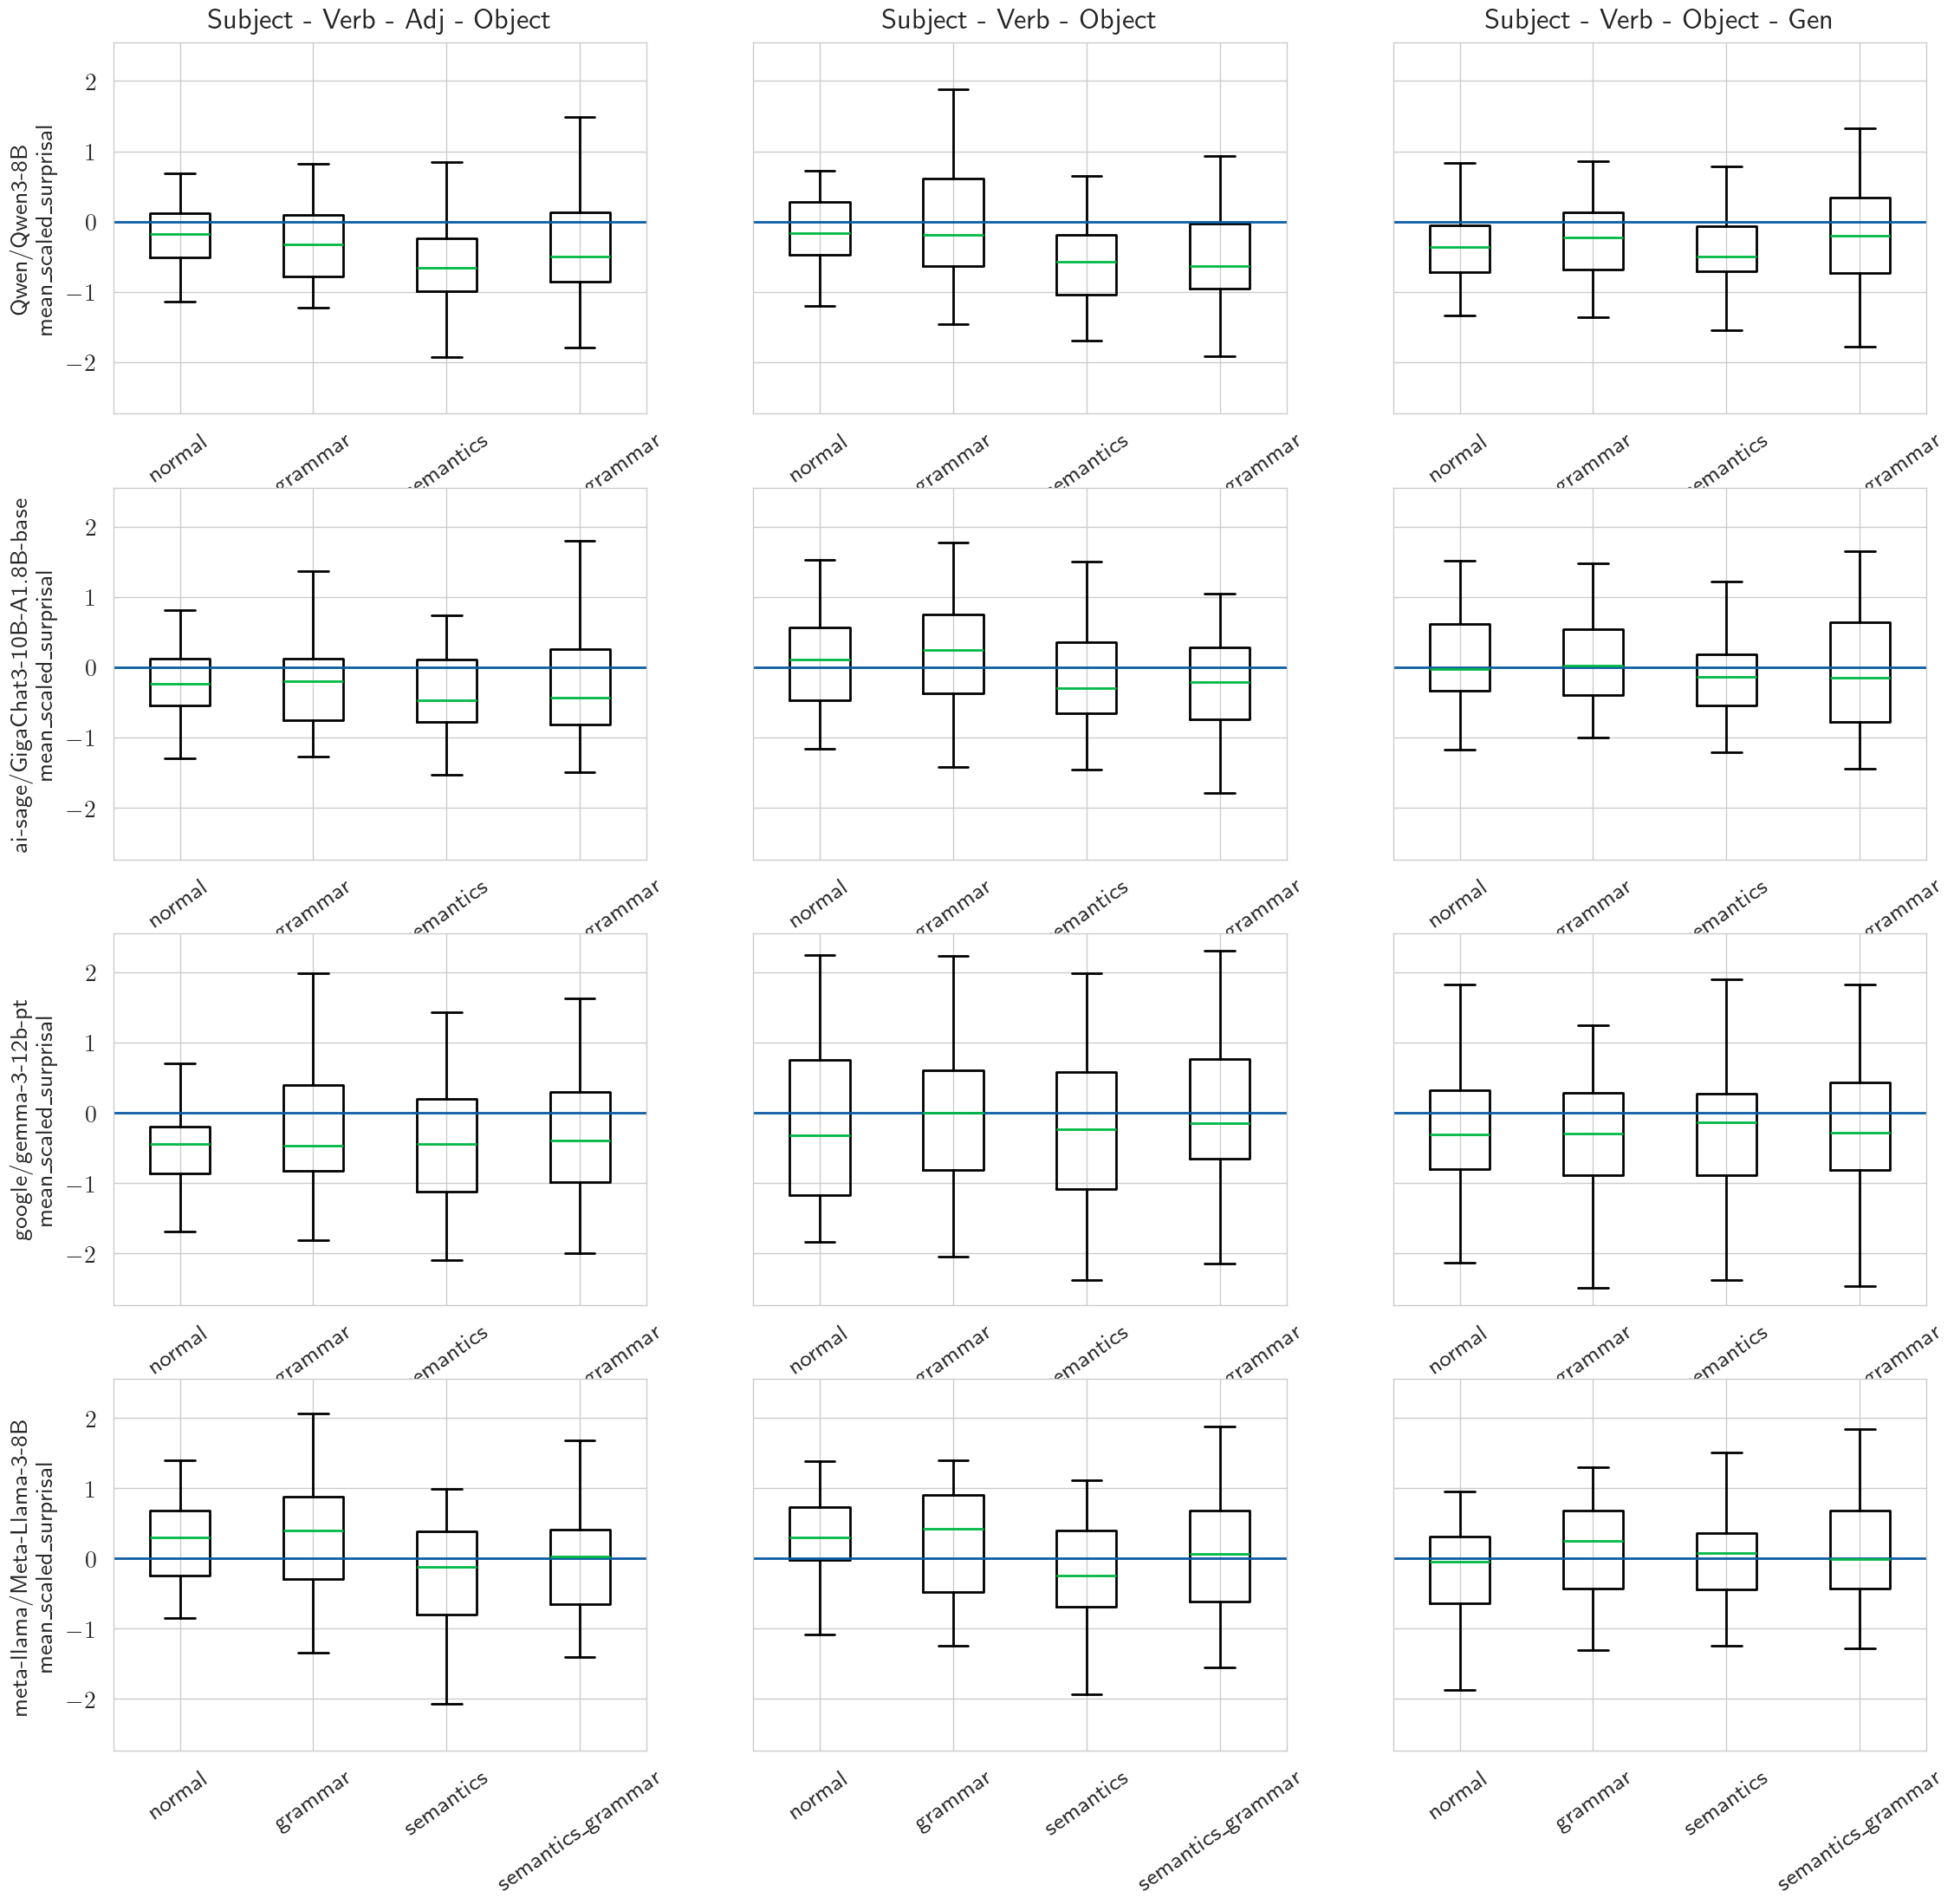

In [14]:

target_order = ["normal","grammar","semantics","semantics_grammar"]
structures = sorted(result["structure"].unique())
nrows, ncols = len(models), len(structures)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4.5*ncols, 3.2*nrows), sharey=True)

for i, m in enumerate(models):
    dm = result[result["model_name"]==m]
    for j, s in enumerate(structures):
        ax = axes[i, j] if nrows>1 else axes[j]
        ds = dm[dm["structure"]==s]
        data = [ds.loc[ds["target"]==t, "mean_scaled_surprisal"].values for t in target_order]
        ax.boxplot(data, labels=target_order, showfliers=False)
        ax.axhline(0, linewidth=1)
        if i == 0:
            ax.set_title(s)
        if j == 0:
            ax.set_ylabel(f"{m}\nmean_scaled_surprisal")
        ax.tick_params(axis='x', rotation=35)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

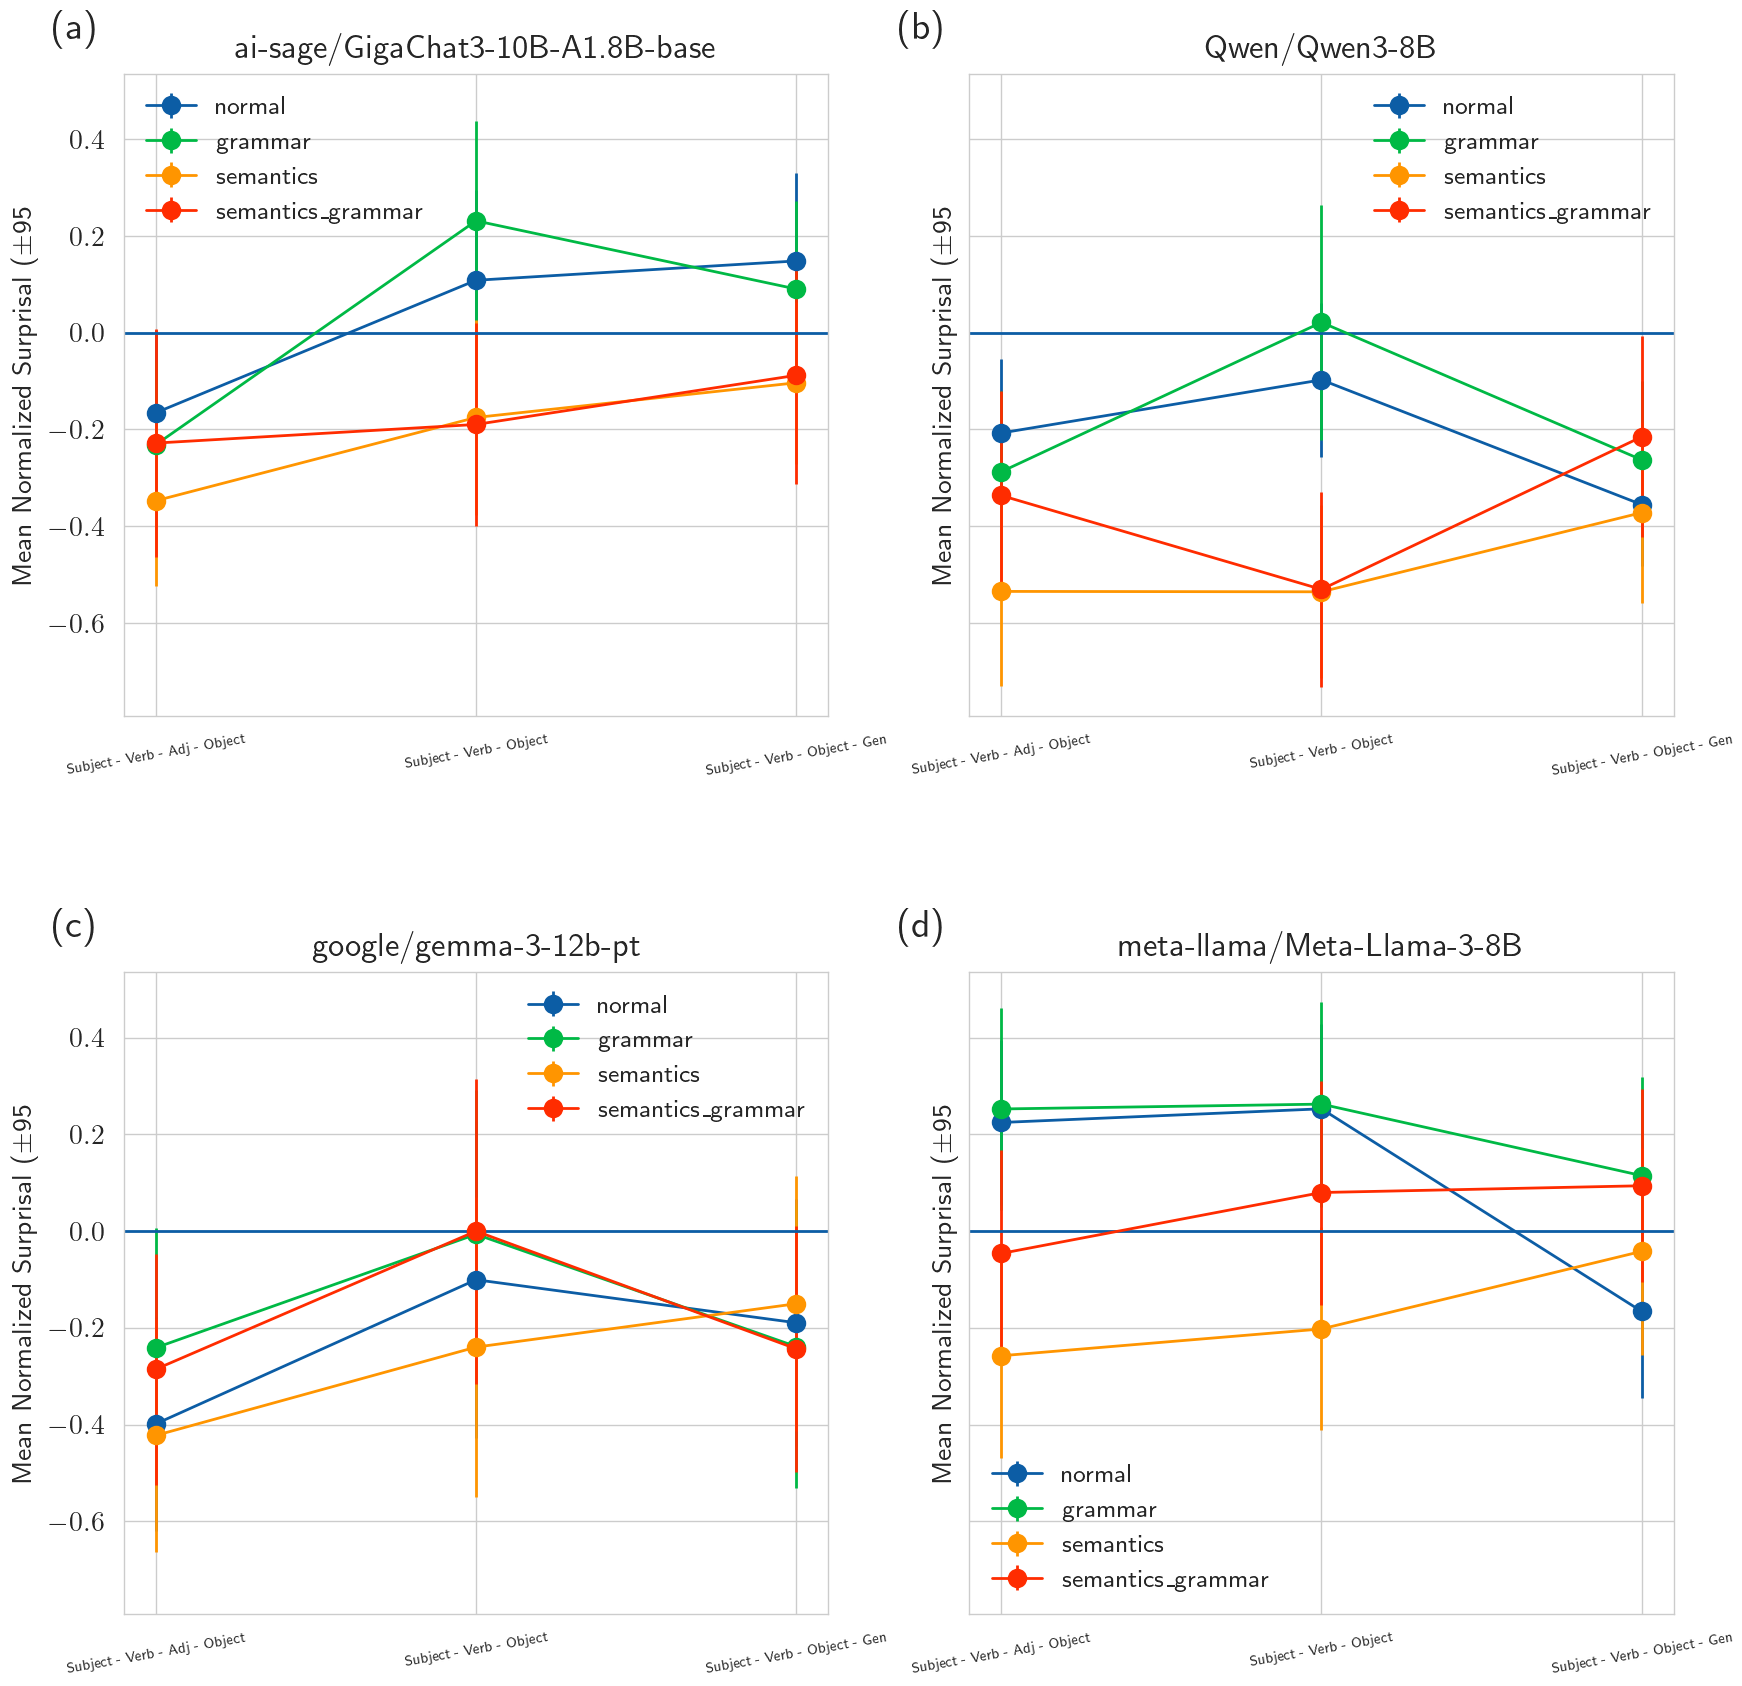

In [15]:
import string


def mean_ci(x):
    m = x.mean()
    se = x.std(ddof=1) / np.sqrt(len(x))
    ci = 1.96 * se
    return m, ci


fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10), sharey=True)
fig.subplots_adjust(hspace=0.4)
axes = axes.flatten()
labels = string.ascii_lowercase
i = 0

for ax, m in zip(axes, result["model_name"].unique()):
    dm = result[result["model_name"] == m]
    x_positions = np.arange(len(structures))
    for t in target_order:
        means = []
        cis = []
        for s in structures:
            vals = dm[(dm["structure"] == s) & (dm["target"] == t)]["mean_scaled_surprisal"]
            mu, ci = mean_ci(vals)
            means.append(mu)
            cis.append(ci)
        ax.errorbar(x_positions, means, yerr=cis, marker='o', linewidth=1, label=t)
    ax.set_title(m)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(structures, rotation=10, ha='center', size=5)
    ax.axhline(0, linewidth=1)
    ax.set_ylabel("Mean Normalized Surprisal (±95% CI)")
    ax.legend(fontsize=9)

    ax.text(
        -0.1, 1.1,
        f"({labels[i]})",
        transform=ax.transAxes,
        fontsize=14,
        fontweight='bold',
        va='top'
    )
    i += 1


plt.show()

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


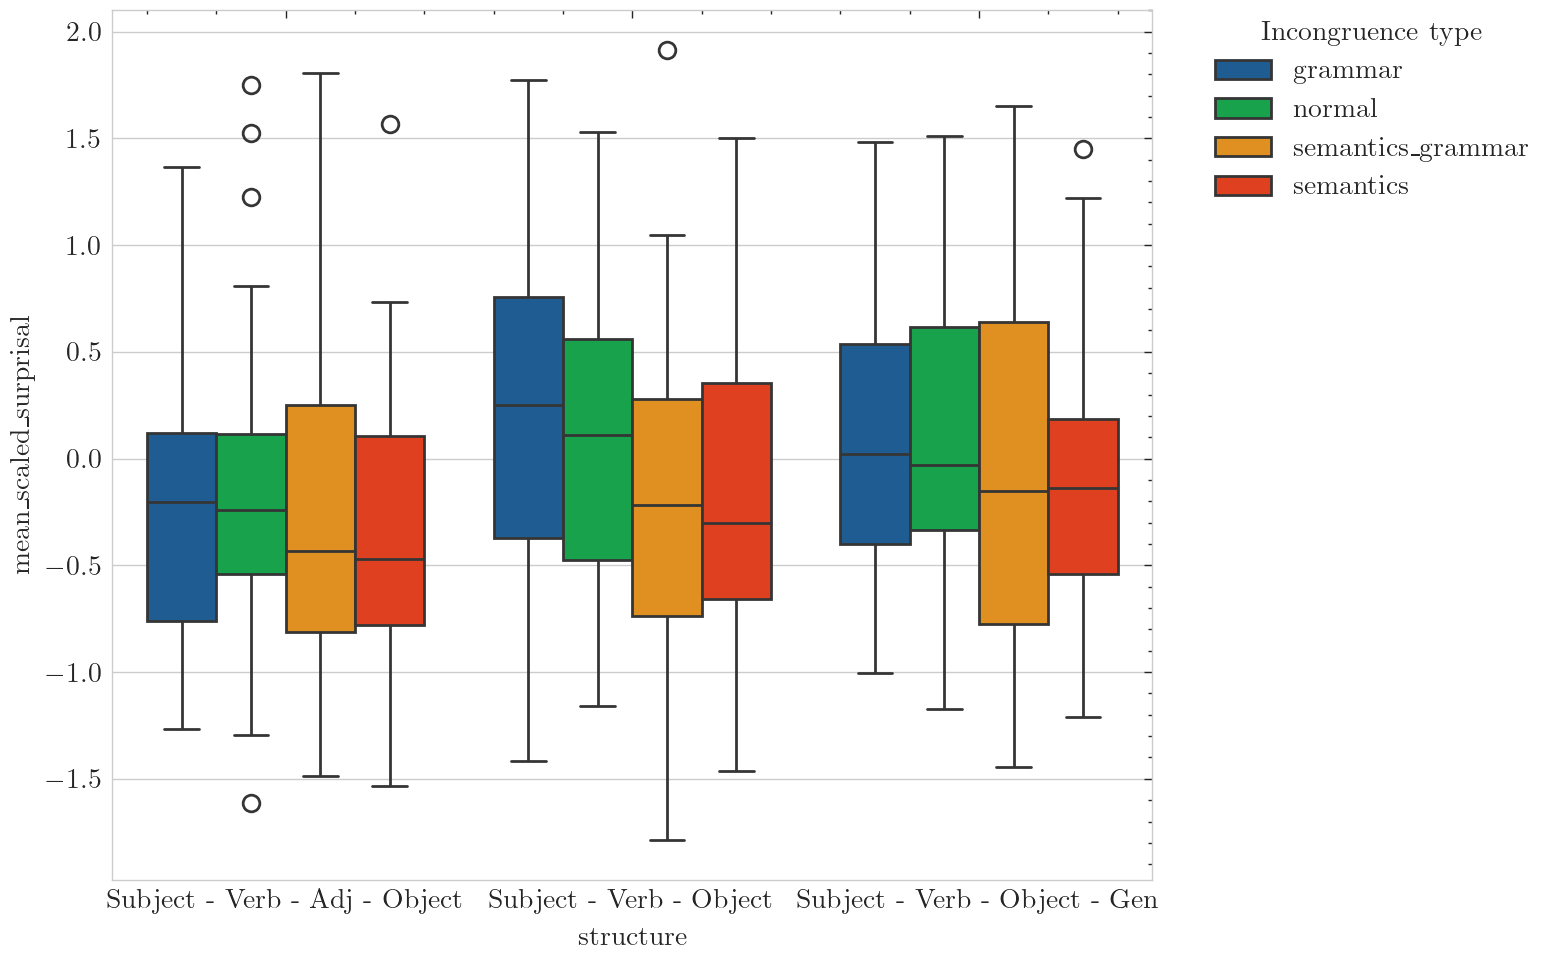

In [52]:
import seaborn as sns

plt.figure(figsize=(8, 5))

ax = sns.boxplot(
    data=df,
    x="structure",
    y="mean_scaled_surprisal",
    hue="target"
)

ax.legend(
    title="Incongruence type",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()
plt.show()


In [25]:
res_df = pd.DataFrame(result_dict)

In [26]:
res_df[["target", "mean_scaled_surprisal"]].to_csv("./target-surp.csv", index=False)

In [11]:
tokenizer = load_tokenizer("ai-sage/GigaChat3-10B-A1.8B-base")

2025-12-09 16:44:08 INFO     src.tokenizer_utils: Tokenizer adds prefix space


In [12]:
result_df = pd.read_csv("../src/results/ai-sage_GigaChat3-10B-A1.8B-base/results.csv")

In [13]:
r = result_df.iloc[0]
r

sentence                        Автобусы проходят массовую дезинфекцией
model                                  ai-sage/GigaChat3-10B-A1.8B-base
instruct                                                          False
hidden_states_path    ./results/ai-sage_GigaChat3-10B-A1.8B-base/000...
logits                ./results/ai-sage_GigaChat3-10B-A1.8B-base/000...
Name: 0, dtype: object

In [14]:
tokens = tokenize(
    tokenizer=tokenizer,
    sentences=[r["sentence"]],
)

In [15]:
token_ids = tokens['input_ids']
token_ids

tensor([[    1, 16553, 40079, 40500, 30876, 38701,   893, 59297,   560,  6637]])

In [18]:


logits = np.load("../src/results/ai-sage_GigaChat3-10B-A1.8B-base/00000_ai-sage_GigaChat3-10B-A1.8B-base.npy_logits.npy")
surp = compute_surprisal(logits, token_ids)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


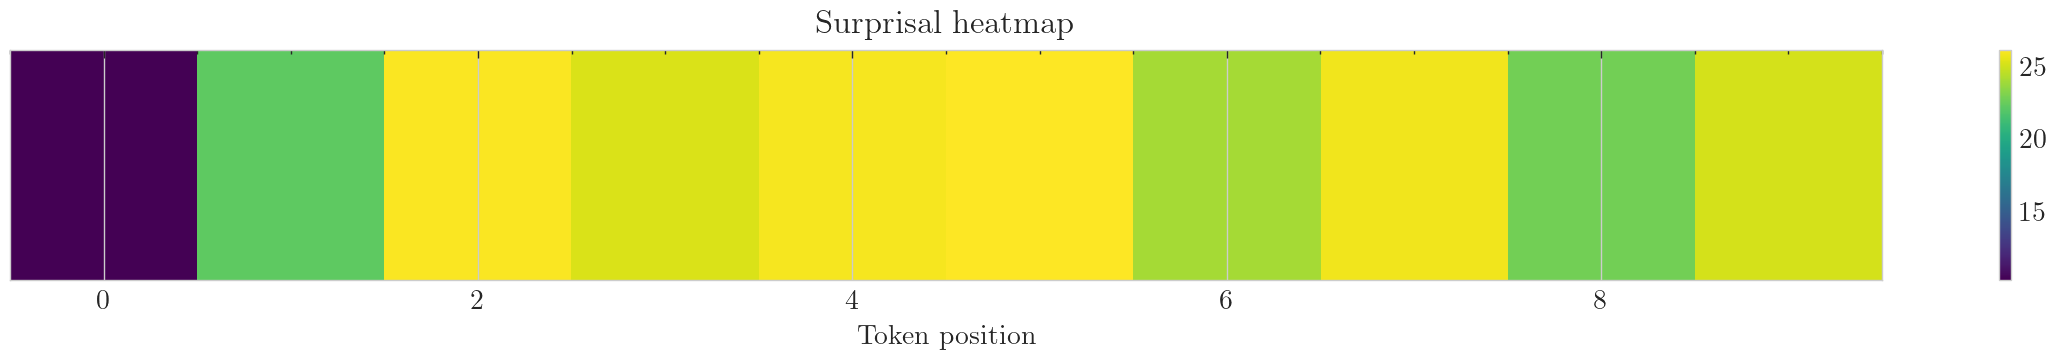

In [19]:


plt.figure(figsize=(12, 2))
plt.imshow(surp, aspect='auto', cmap='viridis')
plt.colorbar()
plt.title("Surprisal heatmap")
plt.xlabel("Token position")
plt.yticks([])
plt.tight_layout()